# MNLP 2026 - Homework 2
Serra 1893530

Falanga 1918515

## 1. Setup & Environment
Import libraries, mount storage, and configure global seeds and paths.

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import json
import pickle
import nltk
import spacy
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import random
import ipywidgets as widgets

from IPython.display import display, clear_output
from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForCausalLM
from nltk.translate.meteor_score import meteor_score
from sklearn.metrics import cohen_kappa_score

# ============================================================
# Runtime detection
# ============================================================

def get_runtime_environment():
    if os.path.exists("/kaggle/input") or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        return "kaggle"

    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

# ENV = get_runtime_environment()
ENV = "colab"
print("Runtime environment:", ENV)

# ============================================================
# Drive mount only on Colab
# ============================================================

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

# ============================================================
# Configuration
# ============================================================

RUN_B1 = False

GROUP = "galline_vecchie_fan_buon_brothers"
TOP_K = 3
BATCH_SIZE = 32
N_LLM_SAMPLES = 200

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.manual_seed(SEED)

print("Device:", device)

# ============================================================
# Paths
# ============================================================

if ENV == "kaggle":
    PROJECT_DIR = "/kaggle/input/mnlp-hw2-serra-falanga"
    IN_DIR = os.path.join(PROJECT_DIR, "inputs")
    OUT_DIR = "/kaggle/working/outputs"

elif ENV == "colab":
    PROJECT_DIR = "/content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA"
    IN_DIR = os.path.join(PROJECT_DIR, "inputs")
    OUT_DIR = os.path.join(PROJECT_DIR, "outputs")

else:
    PROJECT_DIR = "."
    IN_DIR = "./inputs"
    OUT_DIR = "./outputs"

os.makedirs(OUT_DIR, exist_ok=True)


RETRIEVER_PATH = os.path.join(IN_DIR, "minilm_ft_weights.pth")
CHECKPOINT_FILE = os.path.join(IN_DIR, "checkpoint_b1_multi.pkl")
MANUAL_SCORES_PATH = os.path.join(IN_DIR, "manual_scores_progress.json")
WIKIDATA_CACHE_PATH = os.path.join(IN_DIR, "wikidata_cache.json")

print("PROJECT_DIR:", PROJECT_DIR)
print("IN_DIR:", IN_DIR)
print("OUT_DIR:", OUT_DIR)

for name, path in {
    "Retriever weights": RETRIEVER_PATH,
    "B1 checkpoint": CHECKPOINT_FILE,
    "Manual scores": MANUAL_SCORES_PATH,
    "Wikidata cache": WIKIDATA_CACHE_PATH,
}.items():
    print(f"{name}: {path} -> {os.path.exists(path)}")

# ============================================================
# NLTK and dataset
# ============================================================

nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

ds = load_dataset("sapienzanlp-course-materials/hw-mnlp-2026")
test_ds = ds["test"]
blind_ds = ds["blind"]

SMALL_LMS = {
    "qwen3_0_6b": "Qwen/Qwen3-0.6B",
    "smollm2_360m": "HuggingFaceTB/SmolLM2-360M-Instruct",
}

JUDGE_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

FORCE_REFETCH_WIKIDATA = False

print(f"Setup complete. N_LLM_SAMPLES set to {N_LLM_SAMPLES}.")

Runtime environment: colab
Mounted at /content/drive
Device: cuda
PROJECT_DIR: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA
IN_DIR: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs
OUT_DIR: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs
Retriever weights: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/minilm_ft_weights.pth -> True
B1 checkpoint: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/checkpoint_b1_multi.pkl -> True
Manual scores: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/manual_scores_progress.json -> True
Wikidata cache: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/wikidata_cache.json -> True


README.md:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

data/blind-00000-of-00001.parquet:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/66.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating blind split:   0%|          | 0/1322 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Setup complete. N_LLM_SAMPLES set to 200.


In [2]:
# ============================================================
# JSONL saving helpers
# ============================================================

import os
import json
import numpy as np

GROUP = "galline_vecchie_fan_buon_brothers"


def make_json_serializable(obj):
    """Convert numpy objects to standard Python objects for JSON export."""
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_jsonl(records, path):
    """Save a list of dictionaries as JSONL."""
    os.makedirs(os.path.dirname(path), exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        for record in records:
            json.dump(make_json_serializable(record), f, ensure_ascii=False)
            f.write("\n")

    print(f"Saved {len(records)} records to {path}")

In [3]:
import gc

def clear_gpu():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("GPU cache cleared.")

## 2. Baseline 1: Inference
Retrieval and generation for Baseline, RAG, and Oracle configurations.

### 2.1 Retriever

We use the fine-tuned MiniLM bi-encoder from HW1 to retrieve the top-k candidate chunks for each query. Query and candidate chunks are encoded into dense vectors, normalized, and ranked by cosine similarity. We use `TOP_K = 3` for all RAG and Oracle configurations.

In [4]:
# --- Retriever Initialization ---
base_model_name = 'sentence-transformers/all-MiniLM-L6-v2'
retriever = SentenceTransformer(base_model_name, device=device)

print(f"Loading custom weights from {RETRIEVER_PATH}...")
weights = torch.load(RETRIEVER_PATH, map_location=device)
retriever[0].auto_model.load_state_dict(weights, strict=False)

def retrieve_topk_indices(sample, top_k=3):
    query = sample["query"]
    chunks = sample["candidate_chunks"]

    q_emb = retriever.encode(query, convert_to_tensor=True, normalize_embeddings=True)
    c_emb = retriever.encode(chunks, convert_to_tensor=True, normalize_embeddings=True)

    scores = util.cos_sim(q_emb, c_emb)[0]
    topk = torch.topk(scores, k=min(top_k, len(chunks))).indices.cpu().tolist()
    return topk

print("Retriever loaded successfully with fine-tuned weights.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading custom weights from /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/minilm_ft_weights.pth...
Retriever loaded successfully with fine-tuned weights.


### 2.2 Language Models
Loading Small LMs for inference.

In [5]:
def load_lm(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        trust_remote_code=True
    )
    # For batching, padding must be on the left to avoid corrupting the generation
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer, model

### 2.3 Prompting Logic

We define three generation settings:

- **Baseline**: the model receives only the question, without external context.
- **RAG**: the model receives the question plus the top-k chunks retrieved by the MiniLM retriever.
- **Oracle**: the gold chunk is forced into the context, allowing us to estimate how much performance is limited by retrieval versus generation.

All prompts are designed for short-answer factual QA.

In [6]:
def make_baseline_prompt(query):
    return f"""Reply to the question with only the short factual answer.
Do not explain. Do not reason step by step.

Question: {query}
Answer:"""

def make_augmented_prompt(query, chunks):
    context = "\n".join([f"{i+1}. {chunk}" for i, chunk in enumerate(chunks)])
    return f"""Given the following information:

{context}

Reply to the question with only the short factual answer.
Do not explain. Do not reason step by step.

Question: {query}
Answer:"""

def make_oracle_indices(sample, retrieved_indices, top_k=3):
    correct_idx = sample["answer_pos"]
    remaining = [idx for idx in retrieved_indices if idx != correct_idx]
    oracle_indices = [correct_idx] + remaining
    return oracle_indices[:top_k]

### 2.4 Batch Inference
Implementation of the generation loop across data splits.

In [7]:
def clean_generated_answer(text):
    text = text.strip()

    # Remove Qwen3 thinking block if present
    if "</think>" in text:
        text = text.split("</think>", 1)[1].strip()
    elif text.startswith("<think>"):
        text = text.replace("<think>", "", 1).strip()

    # Remove possible answer prefixes
    for prefix in ["Answer:", "Final answer:", "Final Answer:"]:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()

    # Keep only the first non-empty line to encourage short-answer format
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return lines[0] if lines else ""


@torch.inference_mode()
def generate_batch_answers(prompts, tokenizer, model, max_new_tokens=48):
    chat_formatted_prompts = [[{"role": "user", "content": p}] for p in prompts]

    try:
        inputs = tokenizer.apply_chat_template(
            chat_formatted_prompts,
            return_tensors="pt",
            return_dict=True,
            padding=True,
            truncation=True,
            max_length=2048,
            add_generation_prompt=True,
            enable_thinking=False
        ).to(model.device)
    except TypeError:
        inputs = tokenizer.apply_chat_template(
            chat_formatted_prompts,
            return_tensors="pt",
            return_dict=True,
            padding=True,
            truncation=True,
            max_length=2048,
            add_generation_prompt=True
        ).to(model.device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    generated_ids = output_ids[:, inputs["input_ids"].shape[-1]:]
    decoded_outputs = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

    return [clean_generated_answer(text) for text in decoded_outputs]


def save_rag_results(results_list, split_name, short_name, group_name, out_dir):
    if split_name == "test":
        model_filename = f"{group_name}-all-test-{short_name}-rag.jsonl"
    elif split_name == "blind":
        model_filename = f"{group_name}-blind-{short_name}-rag.jsonl"
    else:
        model_filename = f"{group_name}-{split_name}-{short_name}-rag.jsonl"

    save_path = os.path.join(out_dir, model_filename)

    with open(save_path, "w", encoding="utf-8") as f:
        for entry in results_list:
            out_record = {
                "query_id": entry["query_id"],
                "retrieved_chunks": entry["retrieved_chunks"],
                "augmented_prompt": entry["augmented_prompt"],
                "generated_answer": entry["generated_answer"]
            }
            json.dump(out_record, f, ensure_ascii=False)
            f.write("\n")

    print(f"Exported RAG results for {short_name} on {split_name} to {save_path}")


def run_b1_split(data, split_name, model_name, tokenizer, model, include_oracle=True):
    results = {"baseline": [], "rag": [], "oracle": []}

    for i in tqdm(range(0, len(data), BATCH_SIZE), desc=f"{split_name} - {model_name}"):
        batch = data.select(range(i, min(i + BATCH_SIZE, len(data))))
        batch_retrieved_indices = [retrieve_topk_indices(s, TOP_K) for s in batch]

        # Baseline
        b_prompts = [make_baseline_prompt(s["query"]) for s in batch]
        b_ans = generate_batch_answers(b_prompts, tokenizer, model)

        for s, prompt, ans in zip(batch, b_prompts, b_ans):
            results["baseline"].append({
                "query_id": s["query_id"],
                "augmented_prompt": prompt,
                "retrieved_chunks": [],
                "generated_answer": ans
            })

        # RAG
        r_prompts = []
        for s, idxs in zip(batch, batch_retrieved_indices):
            chunks = [s["candidate_chunks"][idx] for idx in idxs]
            r_prompts.append(make_augmented_prompt(s["query"], chunks))

        r_ans = generate_batch_answers(r_prompts, tokenizer, model)

        for s, idxs, prompt, ans in zip(batch, batch_retrieved_indices, r_prompts, r_ans):
            results["rag"].append({
                "query_id": s["query_id"],
                "retrieved_chunks": idxs,
                "augmented_prompt": prompt,
                "generated_answer": ans
            })

        # Oracle
        if include_oracle and "answer_pos" in batch.features:
            oracle_indices_batch = [
                make_oracle_indices(s, idxs, TOP_K)
                for s, idxs in zip(batch, batch_retrieved_indices)
            ]

            o_prompts = []
            for s, oracle_idxs in zip(batch, oracle_indices_batch):
                chunks = [s["candidate_chunks"][idx] for idx in oracle_idxs]
                o_prompts.append(make_augmented_prompt(s["query"], chunks))

            o_ans = generate_batch_answers(o_prompts, tokenizer, model)

            for s, oracle_idxs, prompt, ans in zip(batch, oracle_indices_batch, o_prompts, o_ans):
                results["oracle"].append({
                    "query_id": s["query_id"],
                    "retrieved_chunks": oracle_idxs,
                    "augmented_prompt": prompt,
                    "generated_answer": ans
                })

    return results

### 2.5 Execution
Running inference and saving results.

In [8]:
if RUN_B1:
    all_results_data = {}

    for short_name, hf_id in SMALL_LMS.items():
        print(f"\nProcessing: {hf_id}")
        tokenizer, model = load_lm(hf_id)

        test_res = run_b1_split(
            test_ds,
            split_name="test",
            model_name=short_name,
            tokenizer=tokenizer,
            model=model,
            include_oracle=True
        )

        blind_res = run_b1_split(
            blind_ds,
            split_name="blind",
            model_name=short_name,
            tokenizer=tokenizer,
            model=model,
            include_oracle=False
        )

        all_results_data[short_name] = {
            "test": test_res,
            "blind": blind_res
        }

        # Save only RAG outputs as required by the slides
        save_rag_results(test_res["rag"], "test", short_name, GROUP, OUT_DIR)
        save_rag_results(blind_res["rag"], "blind", short_name, GROUP, OUT_DIR)

        # Save checkpoint after each model
        with open(CHECKPOINT_FILE, "wb") as f:
            pickle.dump({"all_results_data": all_results_data}, f)

        del model, tokenizer
        clear_gpu()

else:
    print(f"Loading results from {CHECKPOINT_FILE}...")
    with open(CHECKPOINT_FILE, "rb") as f:
        all_results_data = pickle.load(f)["all_results_data"]
    print(f"Models loaded from disk: {list(all_results_data.keys())}")

Loading results from /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/checkpoint_b1_multi.pkl...
Models loaded from disk: ['qwen3_0_6b', 'smollm2_360m']


## 3. Baseline 2: Evaluation
Automated metrics, LLM-as-a-Judge, and human validation agreement.

### 3.1 Automated Metrics
Computing EM, subEM, and METEOR across all systems.

In [9]:
def normalize_targets(ts):
    if isinstance(ts, list):
        return [str(t) for t in ts]
    return [str(ts)]


def calculate_em(preds, targets_list):
    scores = []
    for p, ts in zip(preds, targets_list):
        targets = normalize_targets(ts)
        score = any(p.strip().lower() == t.strip().lower() for t in targets)
        scores.append(1 if score else 0)
    return np.mean(scores) * 100


def calculate_sub_em(preds, targets_list):
    scores = []
    for p, ts in zip(preds, targets_list):
        targets = normalize_targets(ts)
        pred = p.strip().lower()
        score = any(t.strip().lower() in pred for t in targets)
        scores.append(1 if score else 0)
    return np.mean(scores) * 100


def calculate_meteor(preds, targets_list):
    scores = []
    for p, ts in zip(preds, targets_list):
        targets = normalize_targets(ts)
        p_tokens = nltk.word_tokenize(p.strip())
        ts_tokens = [nltk.word_tokenize(t.strip()) for t in targets]
        scores.append(meteor_score(ts_tokens, p_tokens))
    return np.mean(scores) * 100

def run_automated_evaluation(results_dict, dataset):
    id_to_short = {s['query_id']: s['short_answer'] for s in dataset}
    report = []
    for cfg in ['baseline', 'rag', 'oracle']:
        data = results_dict.get(cfg, [])
        if not data: continue
        preds = [item['generated_answer'] for item in data]
        targets = [id_to_short[item['query_id']] for item in data]
        report.append({
            "Config": cfg.upper(),
            "EM": calculate_em(preds, targets),
            "subEM": calculate_sub_em(preds, targets),
            "METEOR": calculate_meteor(preds, targets)
        })
    return pd.DataFrame(report)


--- Metrics for qwen3_0_6b ---


,Config,EM,subEM,METEOR
0,BASELINE,0.30,2.15,5.414549
1,RAG,5.65,29.75,30.632669
2,ORACLE,6.70,33.75,34.325515



--- Metrics for smollm2_360m ---


,Config,EM,subEM,METEOR
0,BASELINE,0.75,6.15,8.963478
1,RAG,15.85,32.25,32.878048
2,ORACLE,16.90,34.05,34.617282



Selected Best System for Judge/Manual: smollm2_360m

Comparison plot saved to: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/model_comparison.png


<Figure size 1400x700 with 0 Axes>

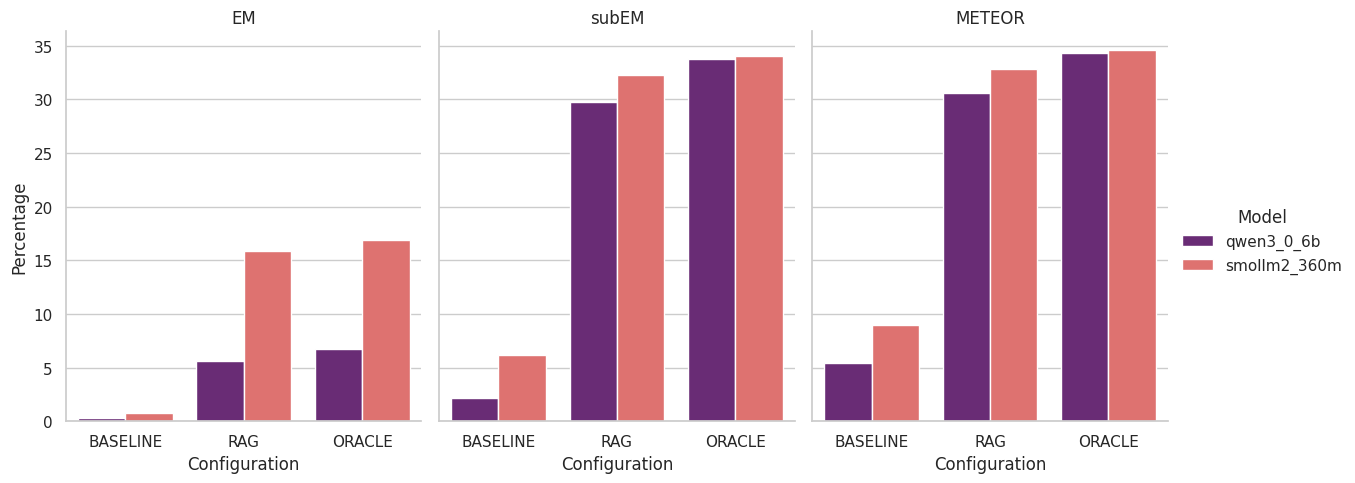

In [10]:
all_reports = {}
for m_name, res in all_results_data.items():
    print(f"\n--- Metrics for {m_name} ---")
    report = run_automated_evaluation(res['test'], test_ds)
    all_reports[m_name] = report
    display(report)

# B2 Requirement: Select best RAG system
best_model_name = max(all_reports, key=lambda m: all_reports[m].loc[all_reports[m]['Config'] == 'RAG', 'METEOR'].values[0])
best_rag_results = all_results_data[best_model_name]['test']['rag']
print(f"\nSelected Best System for Judge/Manual: {best_model_name}")

# --- Visualization & Save to Drive ---
plot_data = []
for m_name, report in all_reports.items():
    m_df = report.copy()
    m_df['Model'] = m_name
    plot_data.append(m_df)

df_plot = pd.concat(plot_data).melt(id_vars=['Config', 'Model'], var_name='Metric', value_name='Percentage')

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Config", y="Percentage", hue="Model", col="Metric",
    palette="magma", height=5, aspect=0.8
)
g.set_axis_labels("Configuration", "Percentage")
g.set_titles("{col_name}")

# Save image to Drive
save_path = os.path.join(OUT_DIR, "model_comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nComparison plot saved to: {save_path}")
plt.show()

### 3.2 LLM-as-a-Judge
Binary evaluation of 200 samples from the best-performing RAG system.

In [11]:
judge_tokenizer, judge_model = load_lm(JUDGE_ID)

def make_llm_eval_prompt(query, ground_truth, generated_answer):
    return f"""Evaluate whether the generated answer contains the correct short answer.

Use this criterion:
- 1 if the correct short answer is present in any valid form.
- 0 if the correct short answer is not present.

Output only 1 or 0.

Query: {query}
Correct short answer: {ground_truth}
Generated answer: {generated_answer}

Score:"""

np.random.seed(SEED)

id_to_sample = {s["query_id"]: s for s in test_ds}
all_test_ids = [s["query_id"] for s in test_ds]

sample_ids = np.random.choice(
    all_test_ids,
    size=N_LLM_SAMPLES,
    replace=False
)

best_rag_map = {
    item["query_id"]: item
    for item in best_rag_results
}

llm_judge_scores = []

for qid in tqdm(sample_ids, desc="LLM Judging"):
    s = id_to_sample[qid]
    generated_answer = best_rag_map[qid]["generated_answer"]

    prompt = make_llm_eval_prompt(
        query=s["query"],
        ground_truth=s["short_answer"],
        generated_answer=generated_answer
    )

    messages = [[{"role": "user", "content": prompt}]]

    inputs = judge_tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        padding=True,
        truncation=True,
        max_length=2048,
        add_generation_prompt=True
    ).to(judge_model.device)

    with torch.no_grad():
        output = judge_model.generate(
            **inputs,
            max_new_tokens=2,
            do_sample=False,
            pad_token_id=judge_tokenizer.pad_token_id,
            eos_token_id=judge_tokenizer.eos_token_id
        )

    prompt_length = inputs["input_ids"].shape[1]
    res = judge_tokenizer.decode(
        output[0, prompt_length:],
        skip_special_tokens=True
    ).strip()

    llm_judge_scores.append(1 if "1" in res else 0)

print(
    f"Judge Evaluation Complete on {len(llm_judge_scores)} samples. "
    f"Judge positive rate: {np.mean(llm_judge_scores) * 100:.2f}%"
)

del judge_model, judge_tokenizer
clear_gpu()

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

LLM Judging:   0%|          | 0/200 [00:00<?, ?it/s]

Judge Evaluation Complete on 200 samples. Judge positive rate: 96.50%
GPU cache cleared.


### 3.3 Manual Validation & Agreement
Calculating Cohen's Kappa between annotators and the LLM Judge.

In [12]:
def save_manual_progress():
    progress = {
        "annotator_1": annotator_1_scores,
        "annotator_2": annotator_2_scores
    }
    with open(MANUAL_SCORES_PATH, "w") as f:
        json.dump(progress, f)

def load_manual_progress():
    if os.path.exists(MANUAL_SCORES_PATH):
        with open(MANUAL_SCORES_PATH, "r") as f:
            data = json.load(f)
            a1 = data.get("annotator_1", [None]*N_LLM_SAMPLES)
            a2 = data.get("annotator_2", [None]*N_LLM_SAMPLES)
            return a1, a2
    return [None]*N_LLM_SAMPLES, [None]*N_LLM_SAMPLES

# Initialization
annotator_1_scores, annotator_2_scores = load_manual_progress()
current_idx = 0
out = widgets.Output()

def update_view():
    with out:
        clear_output(wait=True)
        qid = sample_ids[current_idx]
        sample = id_to_sample[qid]
        rag_ans = best_rag_map[qid]['generated_answer']
        v1_val, v2_val = annotator_1_scores[current_idx], annotator_2_scores[current_idx]

        status = "🟢 Completed" if (v1_val is not None and v2_val is not None) else ("🟡 In Progress" if (v1_val is not None or v2_val is not None) else "🔴 Pending")

        print(f"QID {qid}")
        print(f"SAMPLE {current_idx + 1} / {N_LLM_SAMPLES} | STATUS: {status}")
        print(f"\nQUERY: {sample['query']}")
        print(f"GT: {' | '.join(sample['short_answer'])}")
        print(f"RAG: {rag_ans}")
        print(f"\n--- VOTI ATTUALI ---")
        print(f"Antonio: {'✅' if v1_val==1 else ('❌' if v1_val==0 else '...')}", end=" | ")
        print(f"Daniele: {'✅' if v2_val==1 else ('❌' if v2_val==0 else '...')}")

def set_score(ann_num, score):
    if ann_num == 1: annotator_1_scores[current_idx] = score
    else: annotator_2_scores[current_idx] = score
    save_manual_progress()
    update_view()

def move(step):
    global current_idx
    current_idx = max(0, min(N_LLM_SAMPLES - 1, current_idx + step))
    update_view()

# UI Setup
btn_prev = widgets.Button(description="⬅️ Previous"); btn_prev.on_click(lambda b: move(-1))
btn_next = widgets.Button(description="Next ➡️"); btn_next.on_click(lambda b: move(1))
btn_a1_0 = widgets.Button(description="Antonio: Wrong", button_style='danger'); btn_a1_0.on_click(lambda b: set_score(1, 0))
btn_a1_1 = widgets.Button(description="Antonio: Correct", button_style='success'); btn_a1_1.on_click(lambda b: set_score(1, 1))
btn_a2_0 = widgets.Button(description="Daniele: Wrong", button_style='danger'); btn_a2_0.on_click(lambda b: set_score(2, 0))
btn_a2_1 = widgets.Button(description="Daniele: Correct", button_style='success'); btn_a2_1.on_click(lambda b: set_score(2, 1))

display(widgets.VBox([
    widgets.HBox([btn_prev, btn_next]),
    widgets.HBox([widgets.Label("Antonio:"), btn_a1_0, btn_a1_1]),
    widgets.HBox([widgets.Label("Daniele:"), btn_a2_0, btn_a2_1]),
    out
]))
update_view()

In [13]:
if len(annotator_1_scores) == len(llm_judge_scores) and len(annotator_2_scores) == len(llm_judge_scores):
    # 1. Calculate Automated Metrics on the 200 samples
    sample_rag_data = [best_rag_map[qid] for qid in sample_ids]
    subset_preds = [item['generated_answer'] for item in sample_rag_data]
    subset_targets = [id_to_sample[qid]['short_answer'] for qid in sample_ids]

    subset_em = calculate_em(subset_preds, subset_targets)
    subset_sub_em = calculate_sub_em(subset_preds, subset_targets)
    subset_meteor = calculate_meteor(subset_preds, subset_targets)

    # 2. Calculate Cohen's Kappa
    k_h1_h2 = cohen_kappa_score(annotator_1_scores, annotator_2_scores)
    k_h1_lj = cohen_kappa_score(annotator_1_scores, llm_judge_scores)
    k_h2_lj = cohen_kappa_score(annotator_2_scores, llm_judge_scores)

    # 3. Print All Results
    print(f"--- EVALUATION SUMMARY (Subset of {N_LLM_SAMPLES} samples) ---")
    print(f"System: {best_model_name}\n")

    print("Automated Metrics:")
    print(f"- EM: {subset_em:.2f}")
    print(f"- subEM: {subset_sub_em:.2f}")
    print(f"- METEOR: {subset_meteor:.2f}\n")

    print("Agreement Metrics (Cohen's Kappa):")
    print(f"- Human1 vs Human2: {k_h1_h2:.4f}")
    print(f"- Human1 vs LLM Judge: {k_h1_lj:.4f}")
    print(f"- Human2 vs LLM Judge: {k_h2_lj:.4f}\n")

    print("Judge Performance:")
    print(f"- LLM Judge Positive Rate: {np.mean(llm_judge_scores) * 100:.2f}%\n")

    # 4. Save results to disk
    os.makedirs(OUT_DIR, exist_ok=True)
    output_file = os.path.join(
        OUT_DIR,
        f"{GROUP}-judge-subset-{best_model_name}-rag.jsonl"
    )

    with open(output_file, "w", encoding="utf-8") as f:
        for i, qid in enumerate(sample_ids):
            rag_entry = best_rag_map[qid]
            sample = id_to_sample[qid]

            entry = {
                "query_id": qid,
                "retrieved_chunks": rag_entry["retrieved_chunks"],
                "augmented_prompt": rag_entry["augmented_prompt"],
                "ground_truth": sample["short_answer"],
                "generated_answer": rag_entry["generated_answer"],
                "llm_judge_a": llm_judge_scores[i],
                "annotator_1": annotator_1_scores[i],
                "annotator_2": annotator_2_scores[i]
            }
            json.dump(entry, f, ensure_ascii=False)
            f.write("\n")

    print(f"Evaluation results successfully saved to {output_file}")

else:

    print("Error: Length mismatch between judge scores and manual scores.")

--- EVALUATION SUMMARY (Subset of 200 samples) ---
System: smollm2_360m

Automated Metrics:
- EM: 14.50
- subEM: 32.00
- METEOR: 35.29

Agreement Metrics (Cohen's Kappa):
- Human1 vs Human2: 0.9898
- Human1 vs LLM Judge: 0.0672
- Human2 vs LLM Judge: 0.0688

Judge Performance:
- LLM Judge Positive Rate: 96.50%

Evaluation results successfully saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-judge-subset-smollm2_360m-rag.jsonl


### 3.4 Qualitative Failure Analysis

This section analyzes the 200 manually validated RAG samples by comparing human annotations, the original LLM-as-a-Judge scores, and retrieval evidence.

We distinguish the following cases:

- **judge_false_positive**: the LLM judge marks the answer as correct, but both human annotators mark it as incorrect.
- **judge_false_negative**: the LLM judge marks the answer as incorrect, but both human annotators mark it as correct.
- **retrieval_failure**: the answer is incorrect and the gold chunk is not present among the retrieved top-k chunks.
- **generation_failure**: the answer is incorrect even though the gold chunk is present in the retrieved context.
- **human_disagreement**: the two human annotators disagree.

The goal is to separate failures caused by retrieval, generation, and unreliable automatic judging.

In [14]:
# ============================================================
# Failure Analysis: Model Errors and Judge Disagreements
# ============================================================

import pandas as pd


def format_ground_truth(short_answer):
    """
    Robust formatter for the gold short answer.
    If short_answer is a list, join the valid alternatives.
    If it is a string, return it directly.
    """
    if isinstance(short_answer, list):
        return " | ".join([str(x) for x in short_answer])
    return str(short_answer)


failure_cases = []

for i, qid in enumerate(sample_ids):
    sample = id_to_sample[qid]
    rag_entry = best_rag_map[qid]

    query = sample["query"]
    ground_truth = format_ground_truth(sample["short_answer"])
    generated_answer = rag_entry["generated_answer"]

    retrieved_indices = rag_entry["retrieved_chunks"]
    gold_pos = sample["answer_pos"]

    h1 = annotator_1_scores[i]
    h2 = annotator_2_scores[i]
    judge = llm_judge_scores[i]

    # Human consensus
    if h1 == h2:
        human_consensus = h1
    else:
        human_consensus = "human_disagreement"

    # Check whether the gold chunk was retrieved
    gold_in_topk = gold_pos in retrieved_indices

    if gold_in_topk:
        gold_rank = retrieved_indices.index(gold_pos)
    else:
        gold_rank = None

    # Classify the failure type
    if human_consensus == "human_disagreement":
        error_type = "human_disagreement"

    elif human_consensus == 0 and judge == 1:
        error_type = "judge_false_positive"

    elif human_consensus == 1 and judge == 0:
        error_type = "judge_false_negative"

    elif human_consensus == 0 and judge == 0:
        if gold_in_topk:
            error_type = "generation_failure"
        else:
            error_type = "retrieval_failure"

    else:
        error_type = "correct_agreement"

    # Keep only relevant failure/disagreement cases
    if error_type != "correct_agreement":
        failure_cases.append({
            "sample_index": i,
            "query_id": qid,
            "query": query,
            "ground_truth": ground_truth,
            "generated_answer": generated_answer,
            "annotator_1": h1,
            "annotator_2": h2,
            "llm_judge": judge,
            "human_consensus": human_consensus,
            "retrieved_chunks": retrieved_indices,
            "gold_chunk_position": gold_pos,
            "gold_in_topk": gold_in_topk,
            "gold_rank_in_retrieved": gold_rank,
            "error_type": error_type
        })


failure_df = pd.DataFrame(failure_cases)

print(f"Found {len(failure_cases)} relevant failure/disagreement cases.")

if len(failure_df) > 0:
    print("\nFailure type distribution:")

    summary_df = failure_df["error_type"].value_counts().reset_index()
    summary_df.columns = ["error_type", "count"]

    summary_df["percentage_over_failures"] = (
        summary_df["count"] / len(failure_df) * 100
    )

    summary_df["percentage_over_all_samples"] = (
        summary_df["count"] / len(sample_ids) * 100
    )

    display(summary_df)
    print("\nFailure cases preview:")
    display(failure_df.head(10))
else:
    print("No relevant failure/disagreement cases found.")

Found 88 relevant failure/disagreement cases.

Failure type distribution:


,error_type,count,percentage_over_failures,percentage_over_all_samples
0,judge_false_positive,80,90.909091,40.0
1,generation_failure,4,4.545455,2.0
2,retrieval_failure,2,2.272727,1.0
3,human_disagreement,1,1.136364,0.5
4,judge_false_negative,1,1.136364,0.5



Failure cases preview:


,sample_index,query_id,query,ground_truth,generated_answer,annotator_1,annotator_2,llm_judge,human_consensus,retrieved_chunks,gold_chunk_position,gold_in_topk,gold_rank_in_retrieved,error_type
0,1,6cMFY1k9RzLR,who played the mom on lost in space,June Lockhart,Anne Lockhart,0,0,1,0,"[0, 8, 12]",0,True,0.0,judge_false_positive
1,2,3WiXVGDcPaRK,what is the meaning of black history month,a way for remembering important people and eve...,Black History Month,0,0,1,0,"[0, 1, 10]",0,True,0.0,judge_false_positive
2,8,d7pCGcyjbWTZ,which province of canada has a large french po...,Quebec,Ontario,0,0,0,0,"[0, 44, 19]",0,True,0.0,generation_failure
3,15,JmWYiztfhNuG,where is the young and the restless taped,"CBS Television City, studios 41 and 43 in Holl...","Genoa City, Wisconsin",0,0,0,0,"[0, 30, 28]",10,False,NaN,retrieval_failure
4,18,9vlDB8PI8kN1,who played bass on oh what a night,Don Ciccone,Bob Gaudio and Judy Parker,0,0,1,0,"[1, 0, 4]",1,True,0.0,judge_false_positive
5,19,iq61VUOTuAep,who plays severide's parents on chicago fire,Benny Severide (Treat Williams)Jennifer Sherid...,Taylor Kinney,0,0,0,0,"[1, 3, 10]",3,True,1.0,generation_failure
6,23,ty36AvWsFskb,what hotel was the las vegas shooting in,Mandalay Bay hotel,The Las Vegas Strip,0,0,1,0,"[1, 8, 3]",1,True,0.0,judge_false_positive
7,26,W23TA6jhOvdq,which books of the bible are written in aramaic,DanielEzra,Biblical Aramaic,0,0,1,0,"[0, 6, 2]",0,True,0.0,judge_false_positive
8,29,3LmCdwD5YOGK,where did serena van der woodsen go to college,Columbia,Serena van der Woodsen went to college at the ...,0,0,1,0,"[1, 17, 6]",19,False,NaN,judge_false_positive
9,30,jWMqhHPRF7nQ,who wrote the lyrics to the first time ever i ...,British political singer/songwriter Ewan MacColl,Roberta Flack,0,0,1,0,"[0, 4, 1]",0,True,0.0,judge_false_positive


In [15]:
# ============================================================
# Qualitative Inspection of Failure Cases
# ============================================================

N_CASES_TO_PRINT = 5

for _, case in failure_df.head(N_CASES_TO_PRINT).iterrows():
    qid = case["query_id"]
    sample = id_to_sample[qid]

    print("=" * 100)
    print(f"Error type: {case['error_type']}")
    print(f"Query ID: {qid}")
    print(f"Q: {case['query']}")
    print(f"Ground truth: {case['ground_truth']}")
    print(f"Generated answer: {case['generated_answer']}")
    print(
        f"Scores -> Annotator 1: {case['annotator_1']}, "
        f"Annotator 2: {case['annotator_2']}, "
        f"LLM Judge: {case['llm_judge']}"
    )
    print(f"Gold chunk in top-k: {case['gold_in_topk']}")
    print(f"Gold rank in retrieved chunks: {case['gold_rank_in_retrieved']}")

    print("\nRetrieved chunks:")
    for rank, chunk_idx in enumerate(case["retrieved_chunks"]):
        marker = " <-- GOLD CHUNK" if chunk_idx == sample["answer_pos"] else ""
        chunk_text = sample["candidate_chunks"][chunk_idx]

        print(f"\n[{rank}] Chunk index {chunk_idx}{marker}")
        print(chunk_text[:700].replace("\n", " "))
        if len(chunk_text) > 700:
            print("...")

    print("=" * 100)
    print()

Error type: judge_false_positive
Query ID: 6cMFY1k9RzLR
Q: who played the mom on lost in space
Ground truth: June Lockhart
Generated answer: Anne Lockhart
Scores -> Annotator 1: 0, Annotator 2: 0, LLM Judge: 1
Gold chunk in top-k: True
Gold rank in retrieved chunks: 0.0

Retrieved chunks:

[0] Chunk index 0 <-- GOLD CHUNK
June Lockhart (born June 25, 1925) is an American actress, primarily in 1950s and 1960s television, also with performances on stage and in film. On two television series she played mother roles, Lassie and Lost in Space. She also portrayed Dr. Janet Craig on the CBS television sitcom Petticoat Junction (1968–70). She is a two-time Emmy Award nominee and a Tony Award winner.

[1] Chunk index 8
Lockhart is best known for her roles as TV mothers, first as Ruth Martin, the wife of Paul Martin (portrayed by Hugh Reilly), and the mother of Timmy Martin (played by Jon Provost) in the 1950s CBS series, Lassie (a role that she played from 1958 to 1964). She replaced actress Cl

In [16]:
# ============================================================
# Save Failure Analysis outputs
# ============================================================

if "failure_df" in globals() and len(failure_df) > 0:

    failure_analysis_path = os.path.join(
        OUT_DIR,
        f"{GROUP}-failure-analysis-{best_model_name}-rag.jsonl"
    )

    save_jsonl(
        failure_df.to_dict(orient="records"),
        failure_analysis_path
    )

    print(f"Failure analysis saved to {failure_analysis_path}")

    # Recompute summary to make sure it exists
    failure_summary_df = failure_df["error_type"].value_counts().reset_index()
    failure_summary_df.columns = ["error_type", "count"]

    failure_summary_df["percentage_over_failures"] = (
        failure_summary_df["count"] / len(failure_df) * 100
    )

    failure_summary_df["percentage_over_all_samples"] = (
        failure_summary_df["count"] / len(sample_ids) * 100
    )

    failure_summary_path = os.path.join(
        OUT_DIR,
        f"{GROUP}-failure-analysis-summary-{best_model_name}-rag.csv"
    )

    failure_summary_df.to_csv(failure_summary_path, index=False)

    print(f"Failure analysis summary saved to {failure_summary_path}")

else:
    print("failure_df not found or empty. Skipping failure analysis export.")


Saved 88 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-failure-analysis-smollm2_360m-rag.jsonl
Failure analysis saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-failure-analysis-smollm2_360m-rag.jsonl
Failure analysis summary saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-failure-analysis-summary-smollm2_360m-rag.csv


### 3.5 Numerical Analysis of Results

#### 1. Model Comparison Table

The following table summarizes the performance of the two tested small language models across the three required settings: Baseline, RAG, and Oracle.

| Model | Config | EM (%) | subEM (%) | METEOR (%) |
| :--- | :--- | :--- | :--- | :--- |
| **Qwen-0.6B** | BASELINE | 0.30 | 2.15 | 5.41 |
| | RAG | 5.65 | 27.60 | 30.63 |
| | ORACLE | 6.70 | 33.75 | 34.33 |
| **SmolLM2-360M** | BASELINE | 0.75 | 6.15 | 8.96 |
| | **RAG** | **15.85** | **32.25** | **32.88** |
| | ORACLE | 16.90 | 34.05 | 34.62 |

#### 2. Main Observations

* **Effect of retrieval:** Both models improve substantially when retrieved context is added to the prompt. This confirms that the task cannot be solved reliably using only the models' parametric knowledge, while external retrieved evidence is crucial for factual question answering.

* **Best-performing system:** In our experiments, `SmolLM2-360M` achieves the best overall results, especially in the RAG setting. Although it has fewer parameters than `Qwen-0.6B`, it appears to follow the short-answer QA format more effectively in this setup.

* **RAG vs Oracle:** Oracle improves over standard RAG, but the gap is relatively small. This suggests that the retriever often provides useful evidence in the top-k chunks. However, the remaining gap also shows that retrieval is not perfect and that generation errors can still occur even when relevant context is available.

* **Metric interpretation:** EM remains low because the task expects short factual answers and exact lexical matches are strict. subEM and METEOR are more informative in this setting because they can capture partially correct answers or answers that contain the gold short answer within a longer generation.

#### 3. Human Validation and Judge Reliability

Manual validation showed very high agreement between the two human annotators. In contrast, the LLM-as-a-Judge showed very low agreement with human judgments and a very high positive rate. This indicates that the judge was overly lenient in our setting. Therefore, we treat LLM-based evaluation as a useful but imperfect proxy, and we rely on human validation and qualitative failure analysis to better understand model behavior.

## Additional Requirements [A1]: Different prompting strategies



### A1.1 Query-Aware Context Compression Functions
This section implements Query-Aware Context Compression. Each retrieved chunk is split into sentences. We encode the query and the candidate sentences with MiniLM, compute cosine similarity, and keep the most relevant sentences while preserving their original order. The goal is to reduce noisy or irrelevant context before passing it to the generator.

In [17]:
def compress_context_query_aware(query, chunks, retriever_model, top_sentences_per_chunk=2):
    """Extracts the most relevant sentences from each chunk using cosine similarity."""
    compressed_sentences = []
    q_emb = retriever_model.encode(query, convert_to_tensor=True, normalize_embeddings=True)

    for chunk in chunks:
        sentences = nltk.sent_tokenize(chunk)
        if not sentences:
            continue

        s_embs = retriever_model.encode(
            sentences,
            convert_to_tensor=True,
            normalize_embeddings=True
        )

        cos_sims = util.cos_sim(q_emb, s_embs)[0]

        k = min(top_sentences_per_chunk, len(sentences))
        top_indices = torch.topk(cos_sims, k=k).indices.tolist()

        # Keep original sentence order
        for idx in sorted(top_indices):
            compressed_sentences.append(sentences[idx])

    return compressed_sentences

def make_compressed_rag_prompt(query, chunks, retriever_model):
    """Constructs a RAG prompt using compressed context."""
    compressed_context = compress_context_query_aware(query, chunks, retriever_model)
    context_text = "\n".join([f"{i+1}. {s}" for i, s in enumerate(compressed_context)])

    return f"""Use the following compressed information to answer the question.

{context_text}

Reply to the question with only the shortest factual answer.
If the answer is not present in the context, reply "unknown".
Do not explain. Do not reason step by step.

Question: {query}
Answer:"""

def make_corrective_rag_prompt(query, chunks):
    """Constructs a prompt that asks the model to verify context sufficiency before answering."""
    context = "\n".join([f"{i+1}. {c}" for i, c in enumerate(chunks)])

    return f"""You are a question answering system.

Use only the retrieved context below.
First check whether the context contains enough evidence to answer the question.

If the answer is present in the context, return only the shortest factual answer.
If the answer is not present in the context, return "unknown".

Do not explain.
Do not reason step by step.
Do not use external knowledge.

Retrieved context:
{context}

Question: {query}
Answer:"""

import string

def is_unknown_answer(ans):
    return ans.lower().strip().strip(string.punctuation).strip() == "unknown"

### A1.2 Compressed RAG Generation


In [18]:
print(f"A1.2: Starting Compressed RAG Inference with {best_model_name}...")
tokenizer, model = load_lm(SMALL_LMS[best_model_name])

compressed_rag_results = []
compressed_prompts = []

# Prepare Prompts
for s in tqdm(test_ds, desc="Preparing Compressed Prompts"):
    qid = s['query_id']
    ret_idxs = best_rag_map[qid]['retrieved_chunks']
    actual_chunks = [s['candidate_chunks'][i] for i in ret_idxs]

    prompt = make_compressed_rag_prompt(s['query'], actual_chunks, retriever)
    compressed_prompts.append((qid, ret_idxs, prompt))

# Batch Generation
for i in tqdm(range(0, len(compressed_prompts), BATCH_SIZE), desc="Generating Answers"):
    batch_data = compressed_prompts[i : i + BATCH_SIZE]
    batch_prompts = [item[2] for item in batch_data]

    batch_ans = generate_batch_answers(batch_prompts, tokenizer, model)

    for (qid, ret_idxs, prompt), ans in zip(batch_data, batch_ans):
      compressed_rag_results.append({
        "query_id": qid,
        "retrieved_chunks": ret_idxs,
        "augmented_prompt": prompt,
        "generated_answer": ans
    })


# Cleanup
del model, tokenizer
clear_gpu()

# Save Results in JSONL format
compressed_results_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-all-test-{best_model_name}-compressed-rag.jsonl"
)

save_jsonl(compressed_rag_results, compressed_results_path)

print(f"Inference complete. Results saved to {compressed_results_path}")

A1.2: Starting Compressed RAG Inference with smollm2_360m...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Preparing Compressed Prompts:   0%|          | 0/2000 [00:00<?, ?it/s]

Generating Answers:   0%|          | 0/63 [00:00<?, ?it/s]

GPU cache cleared.
Saved 2000 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-compressed-rag.jsonl
Inference complete. Results saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-compressed-rag.jsonl


### A1.3 Corrective RAG Generation
Running the inference pipeline using the corrective prompt template.

In [19]:
print(f"A1.3: Starting Corrective RAG Inference with {best_model_name}...")
tokenizer, model = load_lm(SMALL_LMS[best_model_name])

corrective_rag_results = []
corrective_prompts = []

# Prepare Prompts
for s in tqdm(test_ds, desc="Preparing Corrective Prompts"):
    qid = s['query_id']
    ret_idxs = best_rag_map[qid]['retrieved_chunks']
    actual_chunks = [s['candidate_chunks'][i] for i in ret_idxs]

    prompt = make_corrective_rag_prompt(s['query'], actual_chunks)
    corrective_prompts.append((qid, ret_idxs, prompt))

# Batch Generation
for i in tqdm(range(0, len(corrective_prompts), BATCH_SIZE), desc="Generating Corrective Answers"):
    batch_data = corrective_prompts[i : i + BATCH_SIZE]
    batch_prompts = [item[2] for item in batch_data]

    batch_ans = generate_batch_answers(batch_prompts, tokenizer, model)

    for (qid, ret_idxs, prompt), ans in zip(batch_data, batch_ans):
      corrective_rag_results.append({
        "query_id": qid,
        "retrieved_chunks": ret_idxs,
        "augmented_prompt": prompt,
        "generated_answer": ans
    })

# Cleanup
del model, tokenizer
clear_gpu()

# Save Results in JSONL format
corrective_results_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-all-test-{best_model_name}-corrective-rag.jsonl"
)

save_jsonl(corrective_rag_results, corrective_results_path)

print(f"Corrective Inference complete. Results saved to {corrective_results_path}")

A1.3: Starting Corrective RAG Inference with smollm2_360m...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Preparing Corrective Prompts:   0%|          | 0/2000 [00:00<?, ?it/s]

Generating Corrective Answers:   0%|          | 0/63 [00:00<?, ?it/s]

GPU cache cleared.
Saved 2000 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-corrective-rag.jsonl
Corrective Inference complete. Results saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-corrective-rag.jsonl


### A1.5 Evaluation: Comparing all A1 Prompting Strategies
We compare Standard RAG, Compressed RAG (if available), and Corrective RAG.

In [20]:
# Map targets
id_to_targets = {s['query_id']: s['short_answer'] for s in test_ds}
full_targets = [id_to_targets[s['query_id']] for s in test_ds]

# Extract predictions
std_preds = [best_rag_map[s['query_id']]['generated_answer'] for s in test_ds]
corr_preds = [res['generated_answer'] for res in corrective_rag_results]

a1_comparison_list = []

# 1. Standard RAG
a1_comparison_list.append({
    "Config": "Standard RAG",
    "EM": calculate_em(std_preds, full_targets),
    "subEM": calculate_sub_em(std_preds, full_targets),
    "METEOR": calculate_meteor(std_preds, full_targets)
})

# 2. Compressed RAG (A1) - check if global variable exists
if 'compressed_rag_results' in globals():
    comp_preds = [res['generated_answer'] for res in compressed_rag_results]
    a1_comparison_list.append({
        "Config": "Compressed RAG (A1)",
        "EM": calculate_em(comp_preds, full_targets),
        "subEM": calculate_sub_em(comp_preds, full_targets),
        "METEOR": calculate_meteor(comp_preds, full_targets)
    })

# 3. Corrective RAG (A1)
a1_comparison_list.append({
    "Config": "Corrective RAG (A1)",
    "EM": calculate_em(corr_preds, full_targets),
    "subEM": calculate_sub_em(corr_preds, full_targets),
    "METEOR": calculate_meteor(corr_preds, full_targets)
})

a1_report = pd.DataFrame(a1_comparison_list)
display(a1_report)

# Save Final Report
#a1_report.to_csv(os.path.join(OUT_DIR, "a1_final_report.csv"), index=False)

# --- Qualitative Analysis of "Unknown" ---
unknown_count = sum(1 for p in corr_preds if is_unknown_answer(p))
std_unknown_count = sum(1 for p in std_preds if is_unknown_answer(p))
unknown_percent = (unknown_count / len(corr_preds)) * 100

print(f"\n--- Corrective Analysis ---")
print(f"Corrective RAG generated 'unknown' {unknown_count} times ({unknown_percent:.2f}% of cases).")
print(f"Standard RAG generated 'unknown' {std_unknown_count} times.")
if unknown_count > std_unknown_count:
    print("Conclusion: Corrective RAG is MORE conservative than Standard RAG.")
else:
    print("Conclusion: Corrective RAG did not significantly increase the unknown rate compared to Standard RAG.")

,Config,EM,subEM,METEOR
0,Standard RAG,15.85,32.25,32.878048
1,Compressed RAG (A1),17.80,32.60,33.327123
2,Corrective RAG (A1),15.60,32.80,32.361796



--- Corrective Analysis ---
Corrective RAG generated 'unknown' 13 times (0.65% of cases).
Standard RAG generated 'unknown' 0 times.
Conclusion: Corrective RAG is MORE conservative than Standard RAG.


## Additional Requirements [A2]: Alternative LLM Judges

This section evaluates whether stronger or differently calibrated LLM judges align better with human annotations than the original SmolLM2 judge used in B2.

### A2.1 Helper Functions

In [21]:
import string
import re

# --- Configuration for A2 ---
A2_CORRECTNESS_JUDGES = {
    "qwen2_5_3b_judge": "Qwen/Qwen2.5-3B-Instruct",
    "qwen2_5_1_5b_judge": "Qwen/Qwen2.5-1.5B-Instruct"
}

A2_FAITHFULNESS_JUDGE = {
    "qwen2_5_3b_faithfulness": "Qwen/Qwen2.5-3B-Instruct"
}

# ============================================================
# A2.1 Helper functions
# ============================================================

def format_ground_truth(short_answer):
    if isinstance(short_answer, list):
        return " | ".join([str(x) for x in short_answer])
    return str(short_answer)

def parse_binary_judge_output(text):
    """Extracts 0 or 1 from the model output, handling various formats."""
    text_clean = text.lower().strip()
    # Try to find '1' or '0' at the very beginning or end, or after 'score:'
    matches = re.findall(r'\b[01]\b', text_clean)
    if matches:
        # If multiple matches, we take the last one as it's often the 'Final Score'
        return int(matches[-1])

    print(f"Warning: Could not parse binary score from: {text}. Defaulting to 0.")
    return 0

def make_a2_correctness_judge_prompt(query, ground_truth, generated_answer):
    return f"""You are an impartial evaluator.

Your task is to decide whether the generated answer contains the correct short answer.

Evaluation criterion:
- Output 1 if the correct short answer is present in the generated answer in any valid form.
- Output 0 if the correct short answer is not present.
- Ignore extra words if the correct answer is clearly present.
- Do not reward answers that mention only a related but wrong entity.
- Do not explain.

Question: {query}
Correct short answer: {ground_truth}
Generated answer: {generated_answer}

Output only 0 or 1:"""

### A2.2 Alternative correctness Judges Inference

In [22]:
# ============================================================
# A2.2 Alternative correctness judges inference
# ============================================================

from tqdm.auto import tqdm

A2_JUDGE_BATCH_SIZE = 8  # use 4 if Colab T4 gives OOM

def generate_judge_outputs_in_batches(prompts, tokenizer, model, desc, batch_size=A2_JUDGE_BATCH_SIZE):
    outputs = []

    for i in tqdm(range(0, len(prompts), batch_size), desc=desc):
        batch_prompts = prompts[i:i + batch_size]

        batch_outputs = generate_batch_answers(
            batch_prompts,
            tokenizer,
            model,
            max_new_tokens=5
        )

        outputs.extend(batch_outputs)

    return outputs


a2_correctness_scores = {}
a2_correctness_raw_outputs = {}

for judge_name, model_id in A2_CORRECTNESS_JUDGES.items():
    print(f"\n--- Running Correctness Judge: {judge_name} ({model_id}) ---")

    tokenizer, model = load_lm(model_id)

    judge_prompts = []

    for qid in sample_ids:
        s = id_to_sample[qid]

        prompt = make_a2_correctness_judge_prompt(
            query=s["query"],
            ground_truth=format_ground_truth(s["short_answer"]),
            generated_answer=best_rag_map[qid]["generated_answer"]
        )

        judge_prompts.append(prompt)

    raw_responses = generate_judge_outputs_in_batches(
        prompts=judge_prompts,
        tokenizer=tokenizer,
        model=model,
        desc=f"A2 correctness - {judge_name}",
        batch_size=A2_JUDGE_BATCH_SIZE
    )

    parsed_scores = [parse_binary_judge_output(res) for res in raw_responses]

    a2_correctness_scores[judge_name] = parsed_scores
    a2_correctness_raw_outputs[judge_name] = raw_responses

    del model, tokenizer
    clear_gpu()

print("\nAlternative correctness evaluation complete.")


--- Running Correctness Judge: qwen2_5_3b_judge (Qwen/Qwen2.5-3B-Instruct) ---


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

A2 correctness - qwen2_5_1_5b_judge:   0%|          | 0/25 [00:00<?, ?it/s]

GPU cache cleared.

Alternative correctness evaluation complete.


In [23]:
# ============================================================
# Save A2 alternative correctness judges results
# ============================================================

a2_alt_judges_records = []

for i, qid in enumerate(sample_ids):
    rag_entry = best_rag_map[qid]

    record = {
        "query_id": qid,
        "retrieved_chunks": rag_entry["retrieved_chunks"],
        "augmented_prompt": rag_entry["augmented_prompt"],
        "generated_answer": rag_entry["generated_answer"],

        # Original B2 judge and human annotations for comparison
        "llm_judge_a": llm_judge_scores[i],
        "annotator_1": annotator_1_scores[i],
        "annotator_2": annotator_2_scores[i],
    }

    # Alternative A2 correctness judges
    for judge_name, scores in a2_correctness_scores.items():
        record[judge_name] = scores[i]

    # Optional: raw textual outputs for debugging/transparency
    for judge_name, raw_outputs in a2_correctness_raw_outputs.items():
        record[f"{judge_name}_raw"] = raw_outputs[i]

    a2_alt_judges_records.append(record)

a2_alt_judges_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a2-alt-correctness-judges-{best_model_name}-rag.jsonl"
)

save_jsonl(a2_alt_judges_records, a2_alt_judges_path)

print(f"Saved A2 alternative correctness judges to: {a2_alt_judges_path}")

Saved 200 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-alt-correctness-judges-smollm2_360m-rag.jsonl
Saved A2 alternative correctness judges to: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-alt-correctness-judges-smollm2_360m-rag.jsonl


### A2.3 Correctness Judge Agreement Analysis

In [24]:
# ============================================================
# A2.3 Correctness judge agreement analysis
# ============================================================

a2_agreement_rows = []

# Helper to add a judge comparison to the report
def add_judge_to_report(name, scores):
    a2_agreement_rows.append({
        "Config": name,
        "Positive Rate (%)": np.mean(scores) * 100,
        "Kappa vs H1": cohen_kappa_score(annotator_1_scores, scores),
        "Kappa vs H2": cohen_kappa_score(annotator_2_scores, scores),
        "Kappa vs Original Judge": cohen_kappa_score(llm_judge_scores, scores)
    })

# Add original judge for comparison
add_judge_to_report("original_judge", llm_judge_scores)

# Add new judges
for judge_name in a2_correctness_scores:
    add_judge_to_report(judge_name, a2_correctness_scores[judge_name])

a2_correctness_agreement_report = pd.DataFrame(a2_agreement_rows)
print("--- A2.3 Agreement Report ---")
display(a2_correctness_agreement_report)

# Create sample-level comparison
a2_correctness_comparison_data = []
for i, qid in enumerate(sample_ids):
    row = {
        "query_id": qid,
        "query": id_to_sample[qid]["query"],
        "ground_truth": format_ground_truth(id_to_sample[qid]["short_answer"]),
        "generated_answer": best_rag_map[qid]["generated_answer"],
        "annotator_1": annotator_1_scores[i],
        "annotator_2": annotator_2_scores[i],
        "original_judge": llm_judge_scores[i]
    }
    for j_name in a2_correctness_scores:
        row[j_name] = a2_correctness_scores[j_name][i]
    a2_correctness_comparison_data.append(row)

a2_correctness_comparison_df = pd.DataFrame(a2_correctness_comparison_data)
executed_judges = list(a2_correctness_scores.keys())

# Mini Failure Analysis (Judge corrections)
print("\n--- Qualitative Analysis: New judges correcting original false positives ---")
# Filter: original judge said 1, humans said 0, but at least one new judge says 0
corrections = a2_correctness_comparison_df[
    (a2_correctness_comparison_df["original_judge"] == 1) &
    (a2_correctness_comparison_df["annotator_1"] == 0) &
    (a2_correctness_comparison_df["annotator_2"] == 0) &
    (a2_correctness_comparison_df[executed_judges].min(axis=1) == 0)
]

display(corrections.head(5))

--- A2.3 Agreement Report ---


,Config,Positive Rate (%),Kappa vs H1,Kappa vs H2,Kappa vs Original Judge
0,original_judge,96.5,0.067228,0.068751,1.000000
1,qwen2_5_3b_judge,38.5,0.572774,0.564038,0.027927
2,qwen2_5_1_5b_judge,53.5,0.818347,0.808120,0.058723



--- Qualitative Analysis: New judges correcting original false positives ---


,query_id,query,ground_truth,generated_answer,annotator_1,annotator_2,original_judge,qwen2_5_3b_judge,qwen2_5_1_5b_judge
1,6cMFY1k9RzLR,who played the mom on lost in space,June Lockhart,Anne Lockhart,0,0,1,0,0
2,3WiXVGDcPaRK,what is the meaning of black history month,a way for remembering important people and eve...,Black History Month,0,0,1,0,1
18,9vlDB8PI8kN1,who played bass on oh what a night,Don Ciccone,Bob Gaudio and Judy Parker,0,0,1,0,0
23,ty36AvWsFskb,what hotel was the las vegas shooting in,Mandalay Bay hotel,The Las Vegas Strip,0,0,1,0,0
26,W23TA6jhOvdq,which books of the bible are written in aramaic,DanielEzra,Biblical Aramaic,0,0,1,0,0


### A2.4 Faithfulness detection inference

In [25]:
# ============================================================
# A2.4 Faithfulness detection inference
# ============================================================

def make_a2_faithfulness_prompt(context, generated_answer):
    return f"""You are a faithfulness evaluator.

Your task is to decide whether the generated answer is supported by the retrieved context.

Important:
- Evaluate only whether the generated answer can be inferred from the retrieved context.
- Do not evaluate whether the answer is factually correct in the real world.
- A factually correct answer is not faithful if it is not supported by the provided context.
- A factually wrong answer can still be faithful if it follows from the provided context.
- Output 1 if the generated answer is supported by the retrieved context.
- Output 0 if the generated answer is not supported by the retrieved context.
- Do not explain.

Retrieved context:
{context}

Generated answer:
{generated_answer}

Output only 0 or 1:"""


print("\n--- Running Faithfulness Detection: Qwen2.5-3B ---")

faithfulness_judge_name = "qwen2_5_3b_faithfulness"
faithfulness_model_id = "Qwen/Qwen2.5-3B-Instruct"

tokenizer, model = load_lm(faithfulness_model_id)

faithfulness_prompts = []
faithfulness_contexts = []

for qid in sample_ids:
    rag_entry = best_rag_map[qid]
    sample = id_to_sample[qid]

    chunks = [
        sample["candidate_chunks"][idx]
        for idx in rag_entry["retrieved_chunks"]
    ]

    context = "\n".join([f"{i+1}. {c}" for i, c in enumerate(chunks)])

    prompt = make_a2_faithfulness_prompt(
        context=context,
        generated_answer=rag_entry["generated_answer"]
    )

    faithfulness_prompts.append(prompt)
    faithfulness_contexts.append(context)

a2_faithfulness_raw_outputs = generate_judge_outputs_in_batches(
    prompts=faithfulness_prompts,
    tokenizer=tokenizer,
    model=model,
    desc="A2 faithfulness",
    batch_size=A2_JUDGE_BATCH_SIZE
)

a2_faithfulness_scores = [
    parse_binary_judge_output(res)
    for res in a2_faithfulness_raw_outputs
]

del model, tokenizer
clear_gpu()

print("Faithfulness detection complete.")


--- Running Faithfulness Detection: Qwen2.5-3B ---


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

A2 faithfulness:   0%|          | 0/25 [00:00<?, ?it/s]

GPU cache cleared.
Faithfulness detection complete.


### A2.5 Faithfulness vs Correct Analysis

In [26]:
# ============================================================
# A2.5 Faithfulness vs correctness analysis
# ============================================================

a2_faithfulness_data = []
for i, qid in enumerate(sample_ids):
    h1, h2 = annotator_1_scores[i], annotator_2_scores[i]
    h_consensus = h1 if h1 == h2 else "human_disagreement"
    f_score = a2_faithfulness_scores[i]

    category = "human_disagreement"
    if h_consensus != "human_disagreement":
        if h_consensus == 1 and f_score == 1: category = "correct_and_faithful"
        elif h_consensus == 1 and f_score == 0: category = "correct_but_not_faithful"
        elif h_consensus == 0 and f_score == 1: category = "incorrect_but_faithful"
        elif h_consensus == 0 and f_score == 0: category = "incorrect_and_not_faithful"

    a2_faithfulness_data.append({
        "query_id": qid,
        "category": category,
        "human_consensus": h_consensus,
        "faithfulness_score": f_score,
        "query": id_to_sample[qid]["query"],
        "ground_truth": format_ground_truth(id_to_sample[qid]["short_answer"]),
        "generated_answer": best_rag_map[qid]["generated_answer"],
        "retrieved_chunks": best_rag_map[qid]["retrieved_chunks"],
        "retrieved_context": faithfulness_contexts[i]
    })

a2_faithfulness_df = pd.DataFrame(a2_faithfulness_data)

# Summary report
a2_faithfulness_summary = a2_faithfulness_df["category"].value_counts().reset_index()
a2_faithfulness_summary.columns = ["category", "count"]
a2_faithfulness_summary["percentage_over_samples"] = (
    a2_faithfulness_summary["count"] / len(sample_ids) * 100
)

print("--- A2.5 Faithfulness Summary ---")
display(a2_faithfulness_summary)

# Qualitative Examples
print("\n--- Examples: Correct but not Faithful (Hallucination of Truth) ---")
display(a2_faithfulness_df[a2_faithfulness_df["category"] == "correct_but_not_faithful"].head(3))

print("\n--- Examples: Incorrect but Faithful (Following wrong context) ---")
display(a2_faithfulness_df[a2_faithfulness_df["category"] == "incorrect_but_faithful"].head(3))

--- A2.5 Faithfulness Summary ---


,category,count,percentage_over_samples
0,incorrect_and_not_faithful,65,32.5
1,correct_and_faithful,61,30.5
2,correct_but_not_faithful,52,26.0
3,incorrect_but_faithful,21,10.5
4,human_disagreement,1,0.5



--- Examples: Correct but not Faithful (Hallucination of Truth) ---


,query_id,category,human_consensus,faithfulness_score,query,ground_truth,generated_answer,retrieved_chunks,retrieved_context
3,AKoUU0cQkFv7,correct_but_not_faithful,1,0,who wrote the happy birthday to you tune,Patty and Mildred J. Hill,Patty and Mildred J. Hill,"[0, 9, 8]","1. ""Happy Birthday to You"", more commonly know..."
4,mgxM0QWG7Tuf,correct_but_not_faithful,1,0,who played adam in bonanza and where is he,"Pernell Elven Roberts, Jr.","Pernell Elven Roberts, Jr.","[0, 10, 2]","1. Pernell Elven Roberts, Jr. (May 18, 1928 – ..."
5,BIxJh6aYZvzQ,correct_but_not_faithful,1,0,who sang i can't help falling in love with you...,Elvis Presley,Elvis Presley,"[0, 4, 8]","1. ""Can't Help Falling in Love"" is a pop balla..."



--- Examples: Incorrect but Faithful (Following wrong context) ---


,query_id,category,human_consensus,faithfulness_score,query,ground_truth,generated_answer,retrieved_chunks,retrieved_context
26,W23TA6jhOvdq,incorrect_but_faithful,0,1,which books of the bible are written in aramaic,DanielEzra,Biblical Aramaic,"[0, 6, 2]",1. Biblical Aramaic is the form of Aramaic tha...
32,MLd2XozzEbHz,incorrect_but_faithful,0,1,who plays the blackfish in game of thrones,Clive Russell,"Brynden ""The Blackfish"" Tully","[0, 5, 10]",1. Clive Russell (born 7 December 1945) is a B...
46,KyntekXv2zld,incorrect_but_faithful,0,1,when did bmw 5 series change body style,"The wagon/estate body style (called ""Touring"")...",The E60/E61 was the fifth generation of the 5 ...,"[19, 0, 23]",1. The E60/E61 is the fifth generation of the ...


In [27]:
# ============================================================
# Save A2 outputs
# ============================================================

# Paths
a2_comparison_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a2-correctness-judge-comparison-{best_model_name}-rag.jsonl"
)

a2_agreement_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a2-correctness-agreement-report-{best_model_name}-rag.csv"
)

a2_faith_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a2-faithfulness-{best_model_name}-rag.jsonl"
)

a2_faith_summary_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a2-faithfulness-summary-{best_model_name}-rag.csv"
)

# Save JSONLs
save_jsonl(
    a2_correctness_comparison_df.to_dict(orient="records"),
    a2_comparison_path
)

save_jsonl(
    a2_faithfulness_df.to_dict(orient="records"),
    a2_faith_path
)

# Save CSVs
a2_correctness_agreement_report.to_csv(
    a2_agreement_path,
    index=False
)

a2_faithfulness_summary.to_csv(
    a2_faith_summary_path,
    index=False
)

print(f"\nAll A2 outputs saved to {OUT_DIR}")
print(f"Saved correctness comparison JSONL: {a2_comparison_path}")
print(f"Saved correctness agreement CSV: {a2_agreement_path}")
print(f"Saved faithfulness JSONL: {a2_faith_path}")
print(f"Saved faithfulness summary CSV: {a2_faith_summary_path}")

Saved 200 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-correctness-judge-comparison-smollm2_360m-rag.jsonl
Saved 200 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-faithfulness-smollm2_360m-rag.jsonl

All A2 outputs saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs
Saved correctness comparison JSONL: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-correctness-judge-comparison-smollm2_360m-rag.jsonl
Saved correctness agreement CSV: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-correctness-agreement-report-smollm2_360m-rag.csv
Saved faithfulness JSONL: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a2-faithfulness-smollm2_360m-rag.jsonl
Saved faithfulness summary CSV: /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_f

## Additional Requirements A3: Wikidata Integration
In this section, we enhance our RAG pipeline by integrating external knowledge from Wikidata. We fetch entity descriptions to provide the model with factual grounding beyond the retrieved document chunks.

### A3.1 Metadata Acquisition
We use the Wikidata API to fetch labels and descriptions. To comply with Wikimedia's policy, we implement:
1.  **Custom User-Agent headers** identifying our project.
2.  **Rate limiting** (1-second delay between requests).
3.  **Exponential backoff** to gracefully handle `429 Too Many Requests` errors.

In [28]:
def load_wikidata_cache():
    if os.path.exists(WIKIDATA_CACHE_PATH) and not FORCE_REFETCH_WIKIDATA:
        print(f"Loading Wikidata cache from {WIKIDATA_CACHE_PATH}...")
        with open(WIKIDATA_CACHE_PATH, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}

def save_wikidata_cache(cache):
    print(f"Saving Wikidata cache to {WIKIDATA_CACHE_PATH}...")
    with open(WIKIDATA_CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

# Load existing data if available
wikidata_cache = load_wikidata_cache()

Loading Wikidata cache from /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/wikidata_cache.json...


In [29]:
def fetch_wikidata_metadata(entity_id, max_retries=10):
    """Fetches label and description from Wikidata API following Wikimedia guidelines."""
    if not entity_id or pd.isna(entity_id):
        return None, None

    url = "https://www.wikidata.org/w/api.php"
    headers = {
        'User-Agent': f'MNLP-HW2-Client/1.0 ({GROUP}; bot-traffic@wikimedia.org)',
        'Api-User-Agent': f'MNLP-HW2-Client/1.0 ({GROUP})'
    }
    params = {
        "action": "wbgetentities",
        "ids": entity_id,
        "languages": "en",
        "props": "labels|descriptions",
        "format": "json"
    }

    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=15)
            if response.status_code == 200:
                data = response.json().get('entities', {}).get(entity_id, {})
                label = data.get('labels', {}).get('en', {}).get('value')
                description = data.get('descriptions', {}).get('en', {}).get('value')
                return label, description
            elif response.status_code == 429:
                wait_time = 2 ** (attempt + 1)
                print(f"[429] Rate limit exceeded. Waiting for {wait_time} seconds...")
                time.sleep(wait_time)
            else:
                print(f"Error {response.status_code}: {response.text}")
                break
        except Exception:
            print(f"[Exception] Request failed. Retrying in 1 second...")
            time.sleep(1)
    return None, None

# Check if we should fetch or use cache
if FORCE_REFETCH_WIKIDATA:
    print("A3.1: Force refetch enabled. Clearing local cache...")
    wikidata_cache = {}

print(f"A3.1: Fetching missing Wikidata metadata for test set...")
for s in tqdm(test_ds):
    w_id = s.get('wikidata_id')
    if w_id and w_id not in wikidata_cache:
        label, desc = fetch_wikidata_metadata(w_id)
        wikidata_cache[w_id] = (label, desc)
        time.sleep(1.0) # Respect rate limits

print(f"Acquisition complete. Items in cache: {len(wikidata_cache)}")

A3.1: Fetching missing Wikidata metadata for test set...


  0%|          | 0/2000 [00:00<?, ?it/s]

Acquisition complete. Items in cache: 1873


In [30]:
# Save the updated cache after the fetching loop completes
save_wikidata_cache(wikidata_cache)

Saving Wikidata cache to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/inputs/wikidata_cache.json...


In [31]:
# Identify and print incomplete Wikidata entries (null labels or descriptions)
incomplete_entries = []

for qid, (label, desc) in wikidata_cache.items():
    if label is None or desc is None:
        incomplete_entries.append({"id": qid, "label": label, "description": desc})

print(f"Found {len(incomplete_entries)} incomplete entries in wikidata_cache.\n")
for entry in incomplete_entries[:10]: # Displaying first 10 for brevity
    print(entry)

if len(incomplete_entries) > 10:
    print("...")

Found 21 incomplete entries in wikidata_cache.

{'id': 'Q7504123', 'label': 'Incense in India', 'description': None}
{'id': 'Q7892472', 'label': 'United States energy independence', 'description': None}
{'id': 'Q24525708', 'label': 'Industrial Revolution in the United States', 'description': None}
{'id': 'Q423480', 'label': 'coffee production in India', 'description': None}
{'id': 'Q24906459', 'label': 'Natural gas and petroleum in Bangladesh', 'description': None}
{'id': 'Q223653', 'label': None, 'description': 'calendaring and mail server developed by Microsoft that runs exclusively on the Microsoft Windows Server product line'}
{'id': 'Q4903174', 'label': 'Bible translations into Greek', 'description': None}
{'id': 'Q491516', 'label': None, 'description': 'American fast food restaurant chain'}
{'id': 'Q7236834', 'label': 'Powers of the United States Congress', 'description': None}
{'id': 'Q6508633', 'label': 'Leaders of the Vietnam War', 'description': None}
...


### A3.2 Wikidata-Enriched RAG Inference
We augment the prompt by injecting the Wikidata description as "Additional Knowledge" at the top of the context. This helps the model reconcile information between the retrieved chunks and structured knowledge.

In [32]:
def make_enriched_prompt(query, chunks, wikidata_desc=None):
    """Creates prompt with Wikidata info at the top, emphasizing short answers."""
    context = "\n".join([f"{i+1}. {c}" for i, c in enumerate(chunks)])
    extra = f"Additional Knowledge (Wikidata): {wikidata_desc}\n" if wikidata_desc else ""

    return f"""{extra}
      Given the information above and the context below:
      {context}

      Reply to the question with only the short factual answer.
      Do not explain. Do not reason step by step.

      Question: {query}
      Answer:"""

print(f"A3.2: Running Enriched RAG Inference (Full Test Set)...")
tokenizer, model = load_lm(SMALL_LMS[best_model_name])
enriched_answers = []

# Prepare all prompts first
enriched_prompts = []
for s in test_ds:
    qid = s['query_id']
    _, desc = wikidata_cache.get(s.get('wikidata_id'), (None, None))
    retrieved_indices = best_rag_map[qid]['retrieved_chunks']
    chunks = [s['candidate_chunks'][i] for i in retrieved_indices]
    enriched_prompts.append(make_enriched_prompt(s['query'], chunks, desc))

# Batch generation
for i in tqdm(range(0, len(enriched_prompts), BATCH_SIZE)):
    batch = enriched_prompts[i : i + BATCH_SIZE]
    batch_ans = generate_batch_answers(batch, tokenizer, model)
    enriched_answers.extend(batch_ans)

del model, tokenizer
clear_gpu()

A3.2: Running Enriched RAG Inference (Full Test Set)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

GPU cache cleared.


### A3.3 Metrics & Evaluation
We compare the performance of the **Standard RAG** versus the **Wikidata-Enriched RAG** using automated metrics (EM, subEM, and METEOR) across the full test set.

In [33]:
# A3.3: Metrics Calculation & Comparison
full_targets = [s['short_answer'] for s in test_ds]
std_preds = [best_rag_map[s['query_id']]['generated_answer'] for s in test_ds]

comparison_data = []

# Standard RAG Metrics
comparison_data.append({
    "Config": "Standard RAG",
    "EM": calculate_em(std_preds, full_targets),
    "subEM": calculate_sub_em(std_preds, full_targets),
    "METEOR": calculate_meteor(std_preds, full_targets)
})

# Wikidata-Enriched RAG Metrics
comparison_data.append({
    "Config": "Wikidata-Enriched RAG",
    "EM": calculate_em(enriched_answers, full_targets),
    "subEM": calculate_sub_em(enriched_answers, full_targets),
    "METEOR": calculate_meteor(enriched_answers, full_targets)
})

final_report = pd.DataFrame(comparison_data)
print("--- A3.3: Final Performance Comparison (Full Test Set) ---")
display(final_report)

--- A3.3: Final Performance Comparison (Full Test Set) ---


,Config,EM,subEM,METEOR
0,Standard RAG,15.85,32.25,32.878048
1,Wikidata-Enriched RAG,15.75,32.70,33.059469


In [34]:
# ============================================================
# Save A3 Wikidata-Enriched RAG outputs in JSONL format
# ============================================================

enriched_rag_results = []

for sample, prompt, answer in zip(test_ds, enriched_prompts, enriched_answers):
    qid = sample["query_id"]
    retrieved_indices = best_rag_map[qid]["retrieved_chunks"]

    enriched_rag_results.append({
        "query_id": qid,
        "retrieved_chunks": retrieved_indices,
        "augmented_prompt": prompt,
        "generated_answer": answer
    })

enriched_results_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-all-test-{best_model_name}-wikidata-rag.jsonl"
)

save_jsonl(enriched_rag_results, enriched_results_path)

print(f"Wikidata-Enriched RAG results saved to {enriched_results_path}")


# Save A3 metrics report
a3_report_path = os.path.join(
    OUT_DIR,
    f"{GROUP}-a3-wikidata-report.csv"
)

final_report.to_csv(a3_report_path, index=False)

print(f"A3 report saved to {a3_report_path}")

Saved 2000 records to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-wikidata-rag.jsonl
Wikidata-Enriched RAG results saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-all-test-smollm2_360m-wikidata-rag.jsonl
A3 report saved to /content/drive/MyDrive/MNLP_HW2_SERRA_FALANGA/outputs/galline_vecchie_fan_buon_brothers-a3-wikidata-report.csv


### A3.4 Final Comprehensive Analysis & Wikidata Impact

#### 1. Final Performance Summary
The table below summarizes the transition from a standard RAG pipeline to one enriched with Wikidata metadata across the full test set for our best-performing model (`SmolLM2-360M`).

| Configuration | EM (%) | subEM (%) | METEOR (%) |
| :--- | :---: | :---: | :---: |
| **Standard RAG** | **15.85** | 32.25 | 32.88 |
| **Wikidata-Enriched RAG** | 15.75 | **32.70** | **33.06** |

#### 2. Qualitative Findings on Wikidata Integration

Wikidata descriptions provide a compact external signal about the entity associated with each query. In our implementation, the description is prepended to the retrieved context as additional knowledge.

The impact is modest. Wikidata slightly improves subEM and METEOR, suggesting that it can sometimes help the model produce answers that partially match the gold answer. However, EM slightly decreases, which indicates that the additional text can also introduce noise or lead to less exact generations.

Overall, Wikidata enrichment is useful as an additional source of entity-level information, but in this setup it does not substantially outperform the standard RAG pipeline.


#### 3. Overall Project Conclusions

The experiments show that retrieval is essential for factual QA with small LMs: both models improve substantially from Baseline to RAG. SmolLM2-360M is the best generator in our setup, especially when combined with retrieved context.

Manual validation also reveals that the original SmolLM2 LLM-as-a-Judge is too permissive, with very low agreement with human annotators. Alternative Qwen judges provide a more reliable automatic evaluation signal.

Among the additional requirements, Query-Aware Context Compression gives the clearest improvement, while Wikidata enrichment provides only marginal gains.